# Кластеризация ЕГЭ (4 если сделаны все задачи)

Рядом лежат данные с координатами точек. Везде используется Евклидово расстояние. Кластером считается набор не менее чем из 30 точек связанных друг с другом. Аномалия это точка находящаяся на расстоянии более 1 от любого кластера.

* Постройте Распределение точек
* Напишите руками DBSCAN и обработайте им все файлы
* Файл 0.xls также решите руками
* Постройте Распределение точек, отметьте принадлежность кластеров цветами
* Отметьте Аномалии отдельным цветом
* Найдите среди в каждом кластере точку расстояние от которой до всех остальных минимально
* Выведите два числа - Среднее абсцисс и ординат центроидов кластеров * 100000

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


In [3]:
from math import sqrt

def dist(p1, p2):
    return sqrt((p1[0] - p2[0])**2 + (p1[1] - p2[1])**2)

43744.9720726905 -47901.12231008099
43744.9720726905 -47901.12231008099


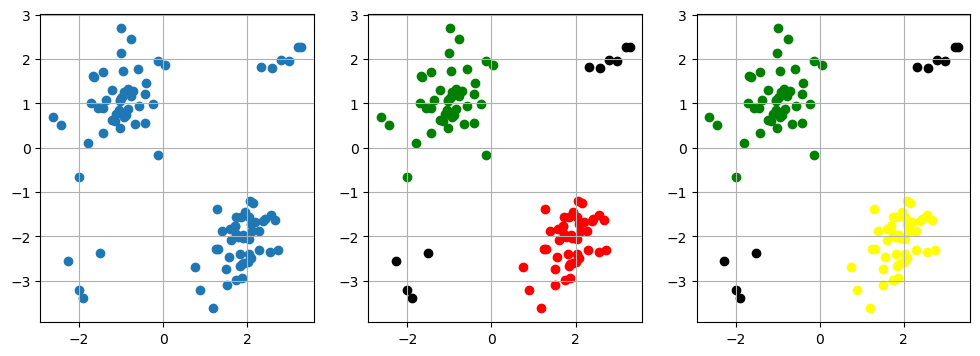

In [26]:
eps = 1.0
min_cnt = 30
comps = []

def build(u, cur_c):
    comps[-1].append(u)
    vis[u] = cur_c
    for v in range(n):
        if vis[v] == -1 and dist(array[u], array[v]) <= eps:
            vis[v] = cur_c
            build(v, cur_c)

df = pd.read_excel('0.xls')
array = df.to_numpy()
x = [el[0] for el in array]
y = [el[1] for el in array]

fig, axs = plt.subplots(1, 3, figsize = (12, 4))
axs[0].scatter(x, y)
axs[0].grid()

n = len(x)
vis = [-1] * n
cur_c = 0
cnt_clasters = 0
ansx = 0
ansy = 0

for i in range(n):
    if vis[i] == -1:
        comps.append([])
        cur_c += 1
        build(i, cur_c)
        if len(comps[-1]) < min_cnt:
            for u in comps[-1]:
                vis[u] = 0
        else:
            cnt_clasters += 1
            best_p = 0
            best_dist = 1e9
            for p1 in comps[-1]:
                cur_dist = 0
                for p2 in comps[-1]:
                    cur_dist += dist(array[p1], array[p2])
                if cur_dist < best_dist:
                    best_dist = cur_dist
                    best_p = p1
            ansx += array[best_p][0]
            ansy += array[best_p][1]
print(ansx / cnt_clasters * 10**5, ansy / cnt_clasters * 10**5)

colors = ['black', 'green', 'red', 'blue', 'yellow']
axs[1].grid()
for i in range(len(comps)):  
    x = [array[u][0] for u in comps[i]]
    y = [array[u][1] for u in comps[i]]
    axs[1].scatter(x, y, color = colors[vis[comps[i][0]]])


arr = [[], [], [], []]
for [x, y] in array:
    if y > -1 and x < 1:
        arr[0].append([x, y])
    elif x > 2 and y > 1:
        arr[1].append([x, y])
    elif x < -1 and y < -2:
        arr[2].append([x, y])
    else:
        arr[3].append([x, y])

axs[2].grid()
ansx2 = 0
ansy2 = 0
for i in range(4):
    x = [el[0] for el in arr[i]]
    y = [el[1] for el in arr[i]]
         
    if len(arr[i]) >= 30:
        best_p = [0, 0]
        best_dist = 1e9
        for p1 in arr[i]:
            cur_dist = 0
            for p2 in arr[i]:
                cur_dist += dist(p1, p2)
            if cur_dist < best_dist:
                best_dist = cur_dist
                best_p = p1
        ansx2 += best_p[0]
        ansy2 += best_p[1]
        axs[2].scatter(x, y, color = colors[i + 1])
    else:
        axs[2].scatter(x, y, color = 'black')
    
print(ansx2 / 2 * 10**5, ansy2 / 2 * 10**5)

In [29]:
import sys
sys.setrecursionlimit(10**5)

99895.16126720734 100091.52172431565


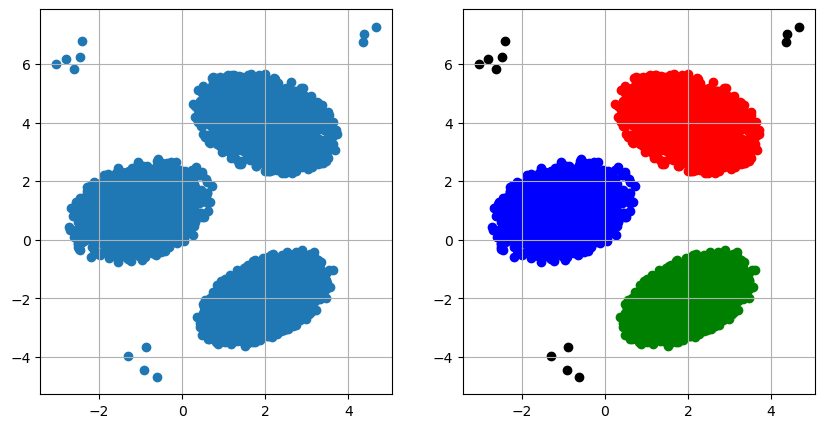

In [33]:
eps = 0.5
min_cnt = 30
comps = []

def build(u, cur_c):
    comps[-1].append(u)
    vis[u] = cur_c
    for v in range(n):
        if vis[v] == -1 and dist(array[u], array[v]) <= eps:
            vis[v] = cur_c
            build(v, cur_c)

df = pd.read_excel('1.xls')
array = df.to_numpy()
x = [el[0] for el in array]
y = [el[1] for el in array]

fig, axs = plt.subplots(1, 2, figsize = (10, 5))
axs[0].scatter(x, y)
axs[0].grid()

n = len(x)
vis = [-1] * n
cur_c = 0
cnt_clasters = 0
ansx = 0
ansy = 0

for i in range(n):
    if vis[i] == -1:
        comps.append([])
        cur_c += 1
        build(i, cur_c)
        if len(comps[-1]) < min_cnt:
            for u in comps[-1]:
                vis[u] = 0
        else:
            cnt_clasters += 1
            best_p = 0
            best_dist = 1e9
            for p1 in comps[-1]:
                cur_dist = 0
                for p2 in comps[-1]:
                    cur_dist += dist(array[p1], array[p2])
                if cur_dist < best_dist:
                    best_dist = cur_dist
                    best_p = p1
            ansx += array[best_p][0]
            ansy += array[best_p][1]
print(ansx / cnt_clasters * 10**5, ansy / cnt_clasters * 10**5)

colors = ['black', 'green', 'red', 'blue', 'yellow']
axs[1].grid()
for i in range(len(comps)):  
    x = [array[u][0] for u in comps[i]]
    y = [array[u][1] for u in comps[i]]
    axs[1].scatter(x, y, color = colors[vis[comps[i][0]]])

515933.15322412294 498987.0954832535


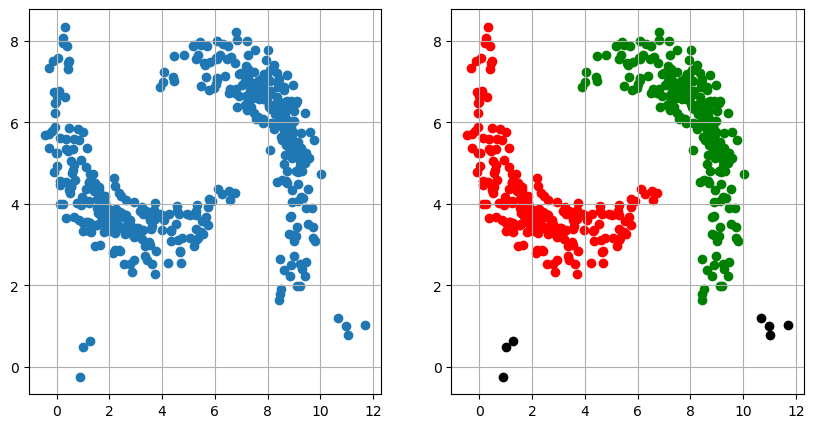

In [39]:
eps = 1.0
min_cnt = 30
comps = []

def build(u, cur_c):
    comps[-1].append(u)
    vis[u] = cur_c
    for v in range(n):
        if vis[v] == -1 and dist(array[u], array[v]) <= eps:
            vis[v] = cur_c
            build(v, cur_c)

array = []
with open('2.txt', 'r') as f:
    for line in f:
        if line[0] != 'X':
            array.append(list(map(float, line.split(','))))
x = [el[0] for el in array]
y = [el[1] for el in array]

fig, axs = plt.subplots(1, 2, figsize = (10, 5))
axs[0].scatter(x, y)
axs[0].grid()

n = len(x)
vis = [-1] * n
cur_c = 0
cnt_clasters = 0
ansx = 0
ansy = 0

for i in range(n):
    if vis[i] == -1:
        comps.append([])
        cur_c += 1
        build(i, cur_c)
        if len(comps[-1]) < min_cnt:
            for u in comps[-1]:
                vis[u] = 0
        else:
            cnt_clasters += 1
            best_p = 0
            best_dist = 1e9
            for p1 in comps[-1]:
                cur_dist = 0
                for p2 in comps[-1]:
                    cur_dist += dist(array[p1], array[p2])
                if cur_dist < best_dist:
                    best_dist = cur_dist
                    best_p = p1
            ansx += array[best_p][0]
            ansy += array[best_p][1]
print(ansx / cnt_clasters * 10**5, ansy / cnt_clasters * 10**5)

colors = ['black', 'green', 'red', 'blue', 'yellow']
axs[1].grid()
for i in range(len(comps)):  
    x = [array[u][0] for u in comps[i]]
    y = [array[u][1] for u in comps[i]]
    axs[1].scatter(x, y, color = colors[vis[comps[i][0]]])

471077.2743145156 409201.5147101898


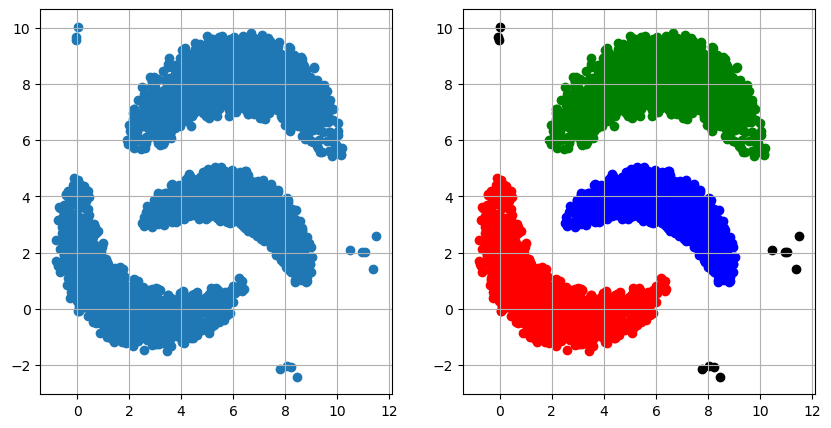

In [41]:
eps = 1.0
min_cnt = 30
comps = []

def build(u, cur_c):
    comps[-1].append(u)
    vis[u] = cur_c
    for v in range(n):
        if vis[v] == -1 and dist(array[u], array[v]) <= eps:
            vis[v] = cur_c
            build(v, cur_c)

array = []
with open('3.txt', 'r') as f:
    for line in f:
        if line[0] != 'X':
            array.append(list(map(float, line.split(','))))
x = [el[0] for el in array]
y = [el[1] for el in array]

fig, axs = plt.subplots(1, 2, figsize = (10, 5))
axs[0].scatter(x, y)
axs[0].grid()

n = len(x)
vis = [-1] * n
cur_c = 0
cnt_clasters = 0
ansx = 0
ansy = 0

for i in range(n):
    if vis[i] == -1:
        comps.append([])
        cur_c += 1
        build(i, cur_c)
        if len(comps[-1]) < min_cnt:
            for u in comps[-1]:
                vis[u] = 0
        else:
            cnt_clasters += 1
            best_p = 0
            best_dist = 1e9
            for p1 in comps[-1]:
                cur_dist = 0
                for p2 in comps[-1]:
                    cur_dist += dist(array[p1], array[p2])
                if cur_dist < best_dist:
                    best_dist = cur_dist
                    best_p = p1
            ansx += array[best_p][0]
            ansy += array[best_p][1]
print(ansx / cnt_clasters * 10**5, ansy / cnt_clasters * 10**5)

colors = ['black', 'green', 'red', 'blue', 'yellow']
axs[1].grid()
for i in range(len(comps)):  
    x = [array[u][0] for u in comps[i]]
    y = [array[u][1] for u in comps[i]]
    axs[1].scatter(x, y, color = colors[vis[comps[i][0]]])

528073.6080153874 71781.45605679341


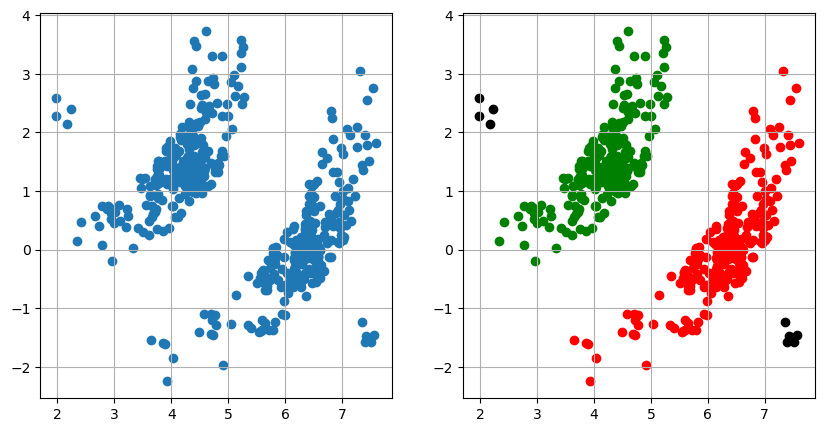

In [43]:
eps = 1.0
min_cnt = 30
comps = []

def build(u, cur_c):
    comps[-1].append(u)
    vis[u] = cur_c
    for v in range(n):
        if vis[v] == -1 and dist(array[u], array[v]) <= eps:
            vis[v] = cur_c
            build(v, cur_c)

array = []
with open('4.txt', 'r') as f:
    for line in f:
        if line[0] != 'X':
            array.append(list(map(float, line.split(','))))
x = [el[0] for el in array]
y = [el[1] for el in array]

fig, axs = plt.subplots(1, 2, figsize = (10, 5))
axs[0].scatter(x, y)
axs[0].grid()

n = len(x)
vis = [-1] * n
cur_c = 0
cnt_clasters = 0
ansx = 0
ansy = 0

for i in range(n):
    if vis[i] == -1:
        comps.append([])
        cur_c += 1
        build(i, cur_c)
        if len(comps[-1]) < min_cnt:
            for u in comps[-1]:
                vis[u] = 0
        else:
            cnt_clasters += 1
            best_p = 0
            best_dist = 1e9
            for p1 in comps[-1]:
                cur_dist = 0
                for p2 in comps[-1]:
                    cur_dist += dist(array[p1], array[p2])
                if cur_dist < best_dist:
                    best_dist = cur_dist
                    best_p = p1
            ansx += array[best_p][0]
            ansy += array[best_p][1]
print(ansx / cnt_clasters * 10**5, ansy / cnt_clasters * 10**5)

colors = ['black', 'green', 'red', 'blue', 'yellow']
axs[1].grid()
for i in range(len(comps)):  
    x = [array[u][0] for u in comps[i]]
    y = [array[u][1] for u in comps[i]]
    axs[1].scatter(x, y, color = colors[vis[comps[i][0]]])

669946.6490070053 370701.4765422124


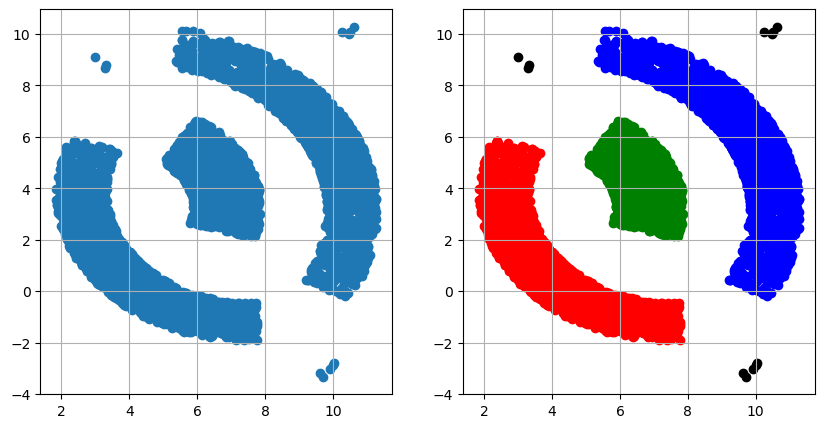

In [45]:
eps = 1.0
min_cnt = 30
comps = []

def build(u, cur_c):
    comps[-1].append(u)
    vis[u] = cur_c
    for v in range(n):
        if vis[v] == -1 and dist(array[u], array[v]) <= eps:
            vis[v] = cur_c
            build(v, cur_c)

array = []
with open('5.txt', 'r') as f:
    for line in f:
        if line[0] != 'X':
            array.append(list(map(float, line.split(','))))
x = [el[0] for el in array]
y = [el[1] for el in array]

fig, axs = plt.subplots(1, 2, figsize = (10, 5))
axs[0].scatter(x, y)
axs[0].grid()

n = len(x)
vis = [-1] * n
cur_c = 0
cnt_clasters = 0
ansx = 0
ansy = 0

for i in range(n):
    if vis[i] == -1:
        comps.append([])
        cur_c += 1
        build(i, cur_c)
        if len(comps[-1]) < min_cnt:
            for u in comps[-1]:
                vis[u] = 0
        else:
            cnt_clasters += 1
            best_p = 0
            best_dist = 1e9
            for p1 in comps[-1]:
                cur_dist = 0
                for p2 in comps[-1]:
                    cur_dist += dist(array[p1], array[p2])
                if cur_dist < best_dist:
                    best_dist = cur_dist
                    best_p = p1
            ansx += array[best_p][0]
            ansy += array[best_p][1]
print(ansx / cnt_clasters * 10**5, ansy / cnt_clasters * 10**5)

colors = ['black', 'green', 'red', 'blue', 'yellow']
axs[1].grid()
for i in range(len(comps)):  
    x = [array[u][0] for u in comps[i]]
    y = [array[u][1] for u in comps[i]]
    axs[1].scatter(x, y, color = colors[vis[comps[i][0]]])

# Кластеризация (1 за каждый алгоритм на всех данных)

На предложенных распределениях данных проверьте предложенные алгоритмы. Постройте графики кластеризации для каждой пары алгоритм-данные, разные кластеры покрасьте разным цветом. Воспользуйтесь sklearn реализациями. Параметры кластеризации для разных алгоритмов подберите такие, чтобы алгоритмы можно было сравнивать (по возможности одинаковое количество кластеров и т.д.)

In [34]:
import time
import warnings

import numpy as np
import matplotlib.pyplot as plt

from sklearn import cluster, datasets, mixture
from sklearn.neighbors import kneighbors_graph
from sklearn.preprocessing import StandardScaler
from itertools import cycle, islice

In [35]:
'''two_means =  
dbscan = 

clustering_algorithms = (
        ("MeanShift", ms),
        ("Spectral\nClustering", spectral),
        ("Ward", ward),
        ("Agglomerative\nClustering", average_linkage),
        ("OPTICS", optics),
        ("Gaussian\nMixture", gmm),
    )'''

'two_means =  \ndbscan = \n\nclustering_algorithms = (\n        ("MeanShift", ms),\n        ("Spectral\nClustering", spectral),\n        ("Ward", ward),\n        ("Agglomerative\nClustering", average_linkage),\n        ("OPTICS", optics),\n        ("Gaussian\nMixture", gmm),\n    )'

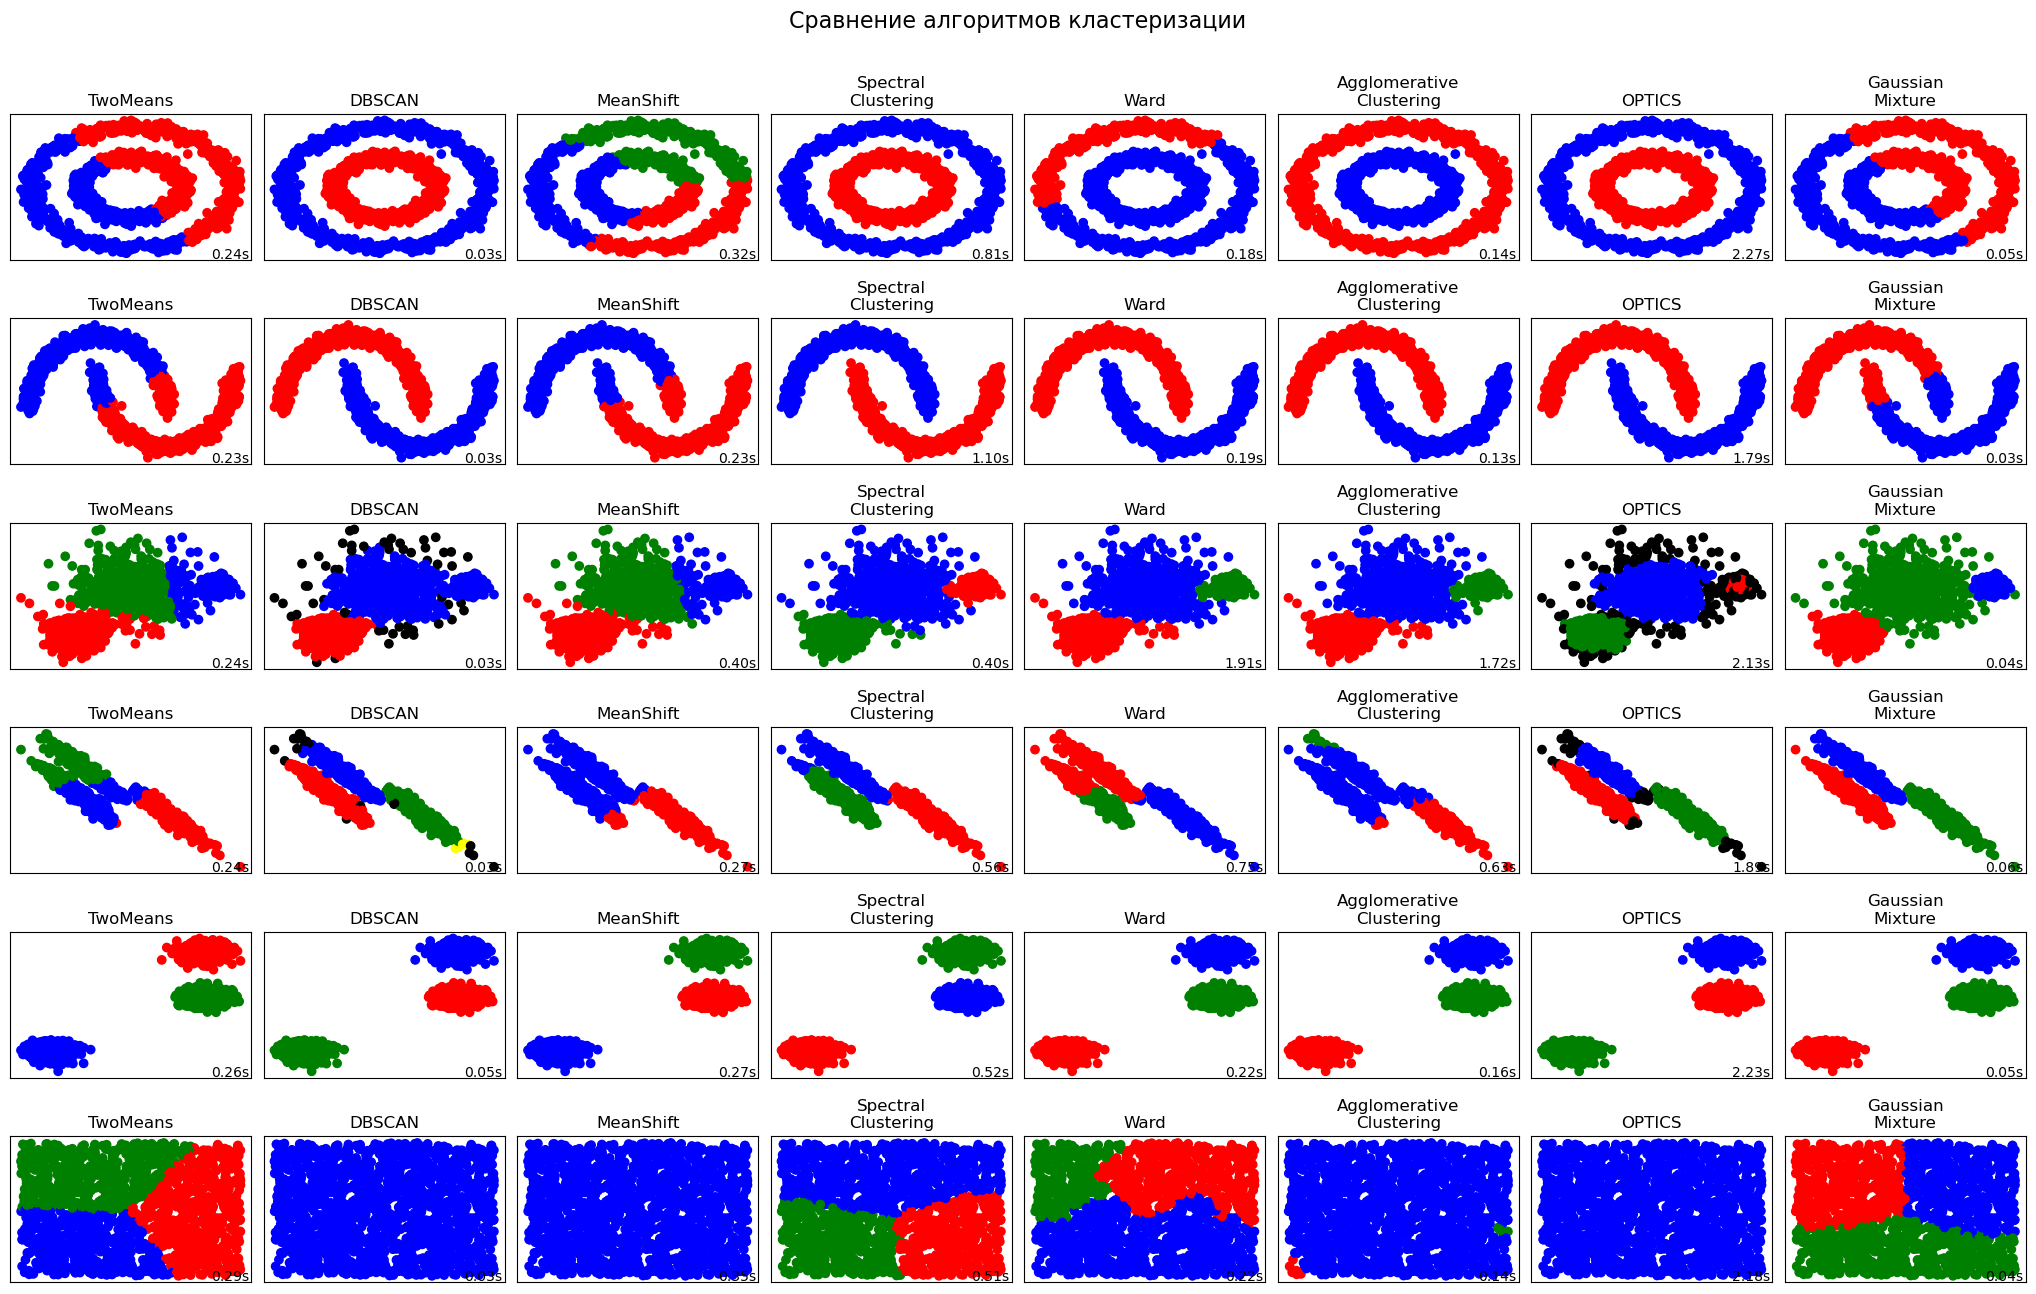

In [36]:
np.random.seed(0)
warnings.filterwarnings("ignore")

# ============
# Generate datasets. We choose the size big enough to see the scalability
# of the algorithms, but not too big to avoid too long running times
# ============
n_samples = 1500
noisy_circles = datasets.make_circles(n_samples=n_samples, factor=0.5, noise=0.05)
noisy_moons = datasets.make_moons(n_samples=n_samples, noise=0.05)
blobs = datasets.make_blobs(n_samples=n_samples, random_state=8)
no_structure = np.random.rand(n_samples, 2), None

# Anisotropicly distributed data
random_state = 170
X, y = datasets.make_blobs(n_samples=n_samples, random_state=random_state)
transformation = [[0.6, -0.6], [-0.4, 0.8]]
X_aniso = np.dot(X, transformation)
aniso = (X_aniso, y)

# blobs with varied variances
varied = datasets.make_blobs(
    n_samples=n_samples, cluster_std=[1.0, 2.5, 0.5], random_state=random_state
)

# ============
# Set up cluster parameters
# ============
plt.figure(figsize=(9 * 2 + 3, 13))
plt.subplots_adjust(
    left=0.02, right=0.98, bottom=0.001, top=0.90, wspace=0.05, hspace=0.4
)

plot_num = 1

default_base = {
    "quantile": 0.3,
    "eps": 0.3,
    "damping": 0.9,
    "preference": -200,
    "n_neighbors": 10,
    "n_clusters": 3,
    "min_samples": 20,
    "xi": 0.05,
    "min_cluster_size": 0.1,
}

datasets = [
    (
        noisy_circles,
        {
            "damping": 0.77,
            "preference": -240,
            "quantile": 0.2,
            "n_clusters": 2,
            "min_samples": 20,
            "xi": 0.25,
        },
    ),
    (noisy_moons, {"damping": 0.75, "preference": -220, "n_clusters": 2}),
    (
        varied,
        {
            "eps": 0.18,
            "n_neighbors": 2,
            "min_samples": 5,
            "xi": 0.035,
            "min_cluster_size": 0.2,
        },
    ),
    (
        aniso,
        {
            "eps": 0.15,
            "n_neighbors": 2,
            "min_samples": 20,
            "xi": 0.1,
            "min_cluster_size": 0.2,
        },
    ),
    (blobs, {}),
    (no_structure, {}),
]

for i_dataset, (dataset, algo_params) in enumerate(datasets):
    # update parameters with dataset-specific values
    params = default_base.copy()
    params.update(algo_params)

    X, y = dataset

    # normalize dataset for easier parameter selection
    X = StandardScaler().fit_transform(X)

    # estimate bandwidth for mean shift
    bandwidth = cluster.estimate_bandwidth(X, quantile=params["quantile"])

    # connectivity matrix for structured Ward
    connectivity = kneighbors_graph(
        X, n_neighbors=params["n_neighbors"], include_self=False
    )
    # make connectivity symmetric
    connectivity = 0.5 * (connectivity + connectivity.T)

    two_means = cluster.KMeans(n_clusters=params["n_clusters"], n_init=10)
    dbscan = cluster.DBSCAN(eps=params["eps"])
    ms = cluster.MeanShift(bandwidth=bandwidth, bin_seeding=True)
    spectral = cluster.SpectralClustering(n_clusters=params["n_clusters"], affinity="nearest_neighbors")
    ward = cluster.AgglomerativeClustering(n_clusters=params["n_clusters"], linkage="ward", connectivity=connectivity)
    average_linkage = cluster.AgglomerativeClustering(linkage="average", affinity="cityblock", 
                                                      n_clusters=params["n_clusters"], connectivity=connectivity)
    optics = cluster.OPTICS(min_samples=params["min_samples"], xi=params["xi"], min_cluster_size=params["min_cluster_size"])
    gmm = mixture.GaussianMixture(n_components=params["n_clusters"], covariance_type="full")

    clustering_algorithms = (
        ("TwoMeans", two_means),
        ("DBSCAN", dbscan),
        ("MeanShift", ms),
        ("Spectral\nClustering", spectral),
        ("Ward", ward),
        ("Agglomerative\nClustering", average_linkage),
        ("OPTICS", optics),
        ("Gaussian\nMixture", gmm),
    )

    for name, algorithm in clustering_algorithms:
        t0 = time.time()

        algorithm.fit(X)
        if hasattr(algorithm, 'labels_'):
            y_pred = algorithm.labels_.astype(int)
        else:
            y_pred = algorithm.predict(X)

        t1 = time.time()
        
        plt.subplot(len(datasets), len(clustering_algorithms), plot_num)

        colors = np.array(['blue', 'red', 'green', 'yellow', 'brown', 'pink', 'purple'])
        colors = np.append(colors, ['black'])  # Для шума в DBSCAN/OPTICS

        plt.scatter(X[:, 0], X[:, 1], color=colors[y_pred])
        plt.title(name)
        plt.xticks([])
        plt.yticks([])
        plt.text(.99, .01, ('%.2fs' % (t1 - t0)),
                 transform=plt.gca().transAxes, size=10,
                 horizontalalignment='right')
        plot_num += 1

plt.suptitle("Сравнение алгоритмов кластеризации", fontsize=16)
plt.show()